/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:25: DeprecationWarning: BICUBIC is deprecated and will be removed in Pillow 10 (2023-07-01). Use Resampling.BICUBIC instead.


number of historical data= 15540


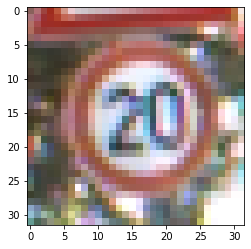

最优树木参数以及最高得分: [180.           0.95632738]


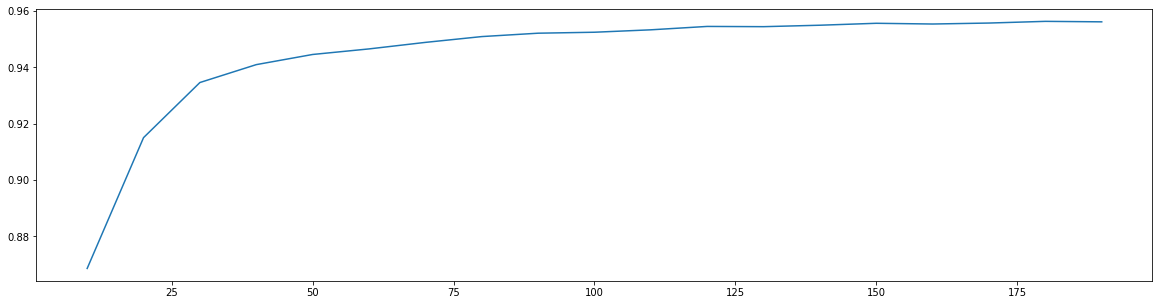

最优树木深度参数以及最高得分: [25.          0.95795759]


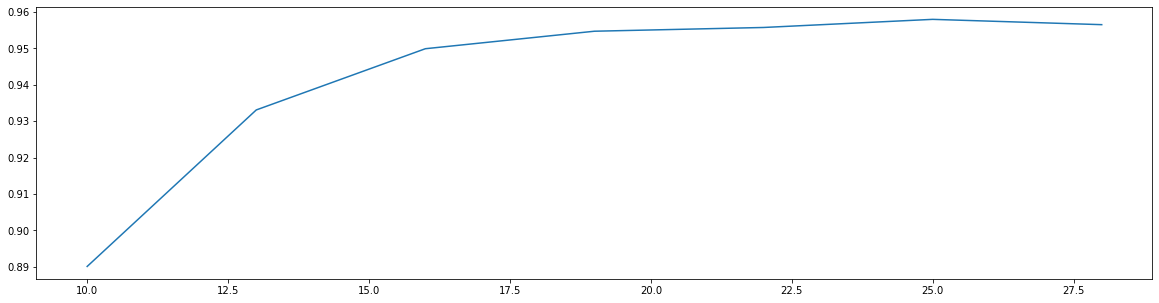

训练开始!
best_params_: {'max_depth': 24, 'n_estimators': 188}
training set cross validation accuracy score: 0.9588155168134895
best_estimator: RandomForestClassifier(max_depth=24, n_estimators=188)
validation: accuracy_score: 0.9814671814671815
training + validation set: model.score 0.9953667953667954
运行结束s时间 69.91169706583023


In [1]:
import matplotlib.pyplot as plt
import csv
from PIL import Image
import numpy as np
from sklearn.metrics import accuracy_score

def readTrafficSigns(rootpath):
    '''Reads traffic sign data 
    Arguments: path to the traffic sign data, for example './TrafficSignData/Training'
    Returns:   list of images, list of corresponding labels'''
    images = [] # images
    labels = [] # corresponding labels
    # loop over N classes, at most we have 42 classes
    N=15
    for c in range(0,N):
        prefix = rootpath + '/' + format(c, '05d') + '/' # subdirectory for class
        gtFile = open(prefix + 'GT-'+ format(c, '05d') + '.csv') # annotations file
        gtReader = csv.reader(gtFile, delimiter=';') # csv parser for annotations file
        #gtReader.next() # skip header
        next(gtReader)
        # loop over all images in current annotations file
        for row in gtReader:
            img=Image.open(prefix + row[0])  # the 1th column is the filename
            # preprocesing image, make sure the images are in the same size
            img=img.resize((32,32), Image.BICUBIC)
            img=np.array(img)
            images.append(img) 
            labels.append(row[7]) # the 8th column is the label
        gtFile.close()
    return images, labels

# load the images
trainImages, trainLabels = readTrafficSigns('/kaggle/input/training/TrafficSignData/Training')
# print number of historical images
print('number of historical data=', len(trainLabels))
# show one sample image
plt.imshow(trainImages[44])
plt.show()

# design the input and output for model
X=[]
Y=[]
for i in range(0,len(trainLabels)):
    # input X just the flattern image, you can design other features to represent a image
    X.append(trainImages[i].flatten())
    Y.append(int(trainLabels[i]))
X=np.array(X)
Y=np.array(Y)



import time
time_start = time.time()  # 记录开始时间

from sklearn.neural_network import MLPClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier 

from sklearn.model_selection import train_test_split,GridSearchCV,cross_val_score


# X 特征值, Y 是目标值.

# 划分测试集 验证集.
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X,Y)


# 找出最佳树木数量.
ScoreAll = []
for i in range(10,200,10):    # 180   (10,200,10)
    DT = RandomForestClassifier(n_estimators = i,random_state = 66) #,criterion = 'entropy'
    score = cross_val_score(DT,X_train,Y_train,cv=2).mean()
    ScoreAll.append([i,score])
ScoreAll = np.array(ScoreAll)


max_score = np.where(ScoreAll==np.max(ScoreAll[:,1]))[0][0] 
print("最优树木参数以及最高得分:",ScoreAll[max_score])  # 答案是180

  
plt.figure(figsize=[20,5])
plt.plot(ScoreAll[:,0],ScoreAll[:,1])
plt.show()

#找出最佳深度.
ScoreAll = []
for i in range(10,30,3):  # 10 20 3
    DT = RandomForestClassifier(n_estimators = 180,max_depth =i,random_state = 66) #,criterion = 'entropy'
    score = cross_val_score(DT,X_train,Y_train,cv=2).mean()
    ScoreAll.append([i,score])
ScoreAll = np.array(ScoreAll)
max_score = np.where(ScoreAll==np.max(ScoreAll[:,1]))[0][0] 
print("最优树木深度参数以及最高得分:",ScoreAll[max_score])  

plt.figure(figsize=[20,5])
plt.plot(ScoreAll[:,0],ScoreAll[:,1])
plt.show()


# 在最佳参数附近,网格搜索.
param_grid = {
  'n_estimators':np.arange(170, 190), # 180     # final : 170 200    # version 12 1 170 190 
  'max_depth':np.arange(24, 26),      # 25      # final : 22 27      # version 12  1 24 26
} 

model = RandomForestClassifier()
model = GridSearchCV(model, param_grid=param_grid, cv=2)# 一般cv=5

# 模型训练和预测
print('训练开始!')
model.fit(X_train,Y_train)   # 训练，找到最优的参数，同时使用最优的参数实例化一个新的 decision tree.
Ypred=model.predict(X_test)
# print(Ypred)


# 模型评估
print('best_params_:',model.best_params_)
print('training set cross validation accuracy score:',model.best_score_) # 交叉验证的准确率
print('best_estimator:',model.best_estimator_)
print('validation: accuracy_score:',accuracy_score(Y_test,Ypred))
print('training + validation set: model.score',model.score(X,Y))



time_end = time.time()  # 记录结束时间
time_sum = time_end - time_start  # 计算的时间差为程序的执行时间，单位为秒/s
print('运行结束s时间',time_sum/60)

# save model
import pickle
pickle.dump(model,open('random_tree_model.sav','wb'))
